# **Détection par apprentissage profond non supervisé (pour ombrage fin)**

**Méthodologie :**

**Modèle de référence**

Un auto-encodeur débruiteur empilé est entraîné sur des données historiques de production photovoltaïque afin d'apprendre les profils de production journaliers normaux de chaque onduleur.

En reconstruisant des profils de production nets et robustes au bruit, le modèle capture implicitement le comportement attendu d'un système photovoltaïque non ombragé, sans nécessiter d'informations physiques ou météorologiques.

**Détection d'anomalies**

Les événements d'ombrage sont identifiés grâce à l'erreur de reconstruction entre le signal observé et sa reconstruction par l'auto-encodeur.

Un seuil adaptatif, dérivé de la distribution de l'erreur, permet la détection d'anomalies subtiles et de courte durée qui n'affectent pas significativement le rendement énergétique journalier et qui sont généralement manquées par les méthodes statistiques.

**Localisation temporelle**

La technique de l'alignement temporel dynamique (DTW) est appliquée aux journées anormales afin d'aligner les profils de production reconstruits et observés et de localiser précisément les événements d'ombrage dans le temps.

Cela permet d'identifier les pertes de production brèves et localisées causées par des obstructions transitoires telles que des feuilles, des oiseaux ou une couverture nuageuse partielle.

## **1. Préparation des données**

### **1.1. Importer les librairies**

In [45]:
%pip install fastdtw

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pvlib
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GaussianNoise, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import savgol_filter
import calendar
from scipy.ndimage import uniform_filter1d
import pandas as pd
import numpy as np
from scipy.spatial.distance import euclidean
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import convolve1d

### **1.2. Configuration des paramètres**

In [47]:
# Paramètres système
TIME_COL = "measured_on"
ALL_INVERTER_IDS = range(1, 25)
OUTLIER_THRESHOLD_KW = 40  # Seuil pour exclure les onduleurs anormaux
SPLIT_RATIO = 0.80
RANDOM_SEED = 42

# Paramètres PVLib
LATITUDE = 38.996306
LONGITUDE = -122.134111
TZ = 'America/Los_Angeles'
DEFAULT_TILT = 25
DEFAULT_AZIMUTH = 180
SYSTEM_EFFICIENCY = 0.18  # Efficacité typique système PV
ALBEDO = 0.2

### **1.3. Charger les données**

In [48]:
# Charger les données
df_clear = pd.read_csv("farm_array_elec_clearsky.csv", parse_dates=["measured_on"])

### **1.4. Scaling individuel par onduleur**

------------------------------------

On transforme la série temporelle en matrice (jours × pas de temps), ce qui est indispensable pour l’autoencodeur.

Pour cela, on définit la fonction build_daily_matrix qui prend en paramètres un Dataframe `df` et une `power_col` (colonne avec la puissance d'un inverteur, dans notre cas : inv_1_ac_power). 

Cette fonction réalise un pivot sur le Dataframe en prenant en index la colonne "date" et en columns les éléments de la colonne "time" (heure par écart de 5 minutes), les valeurs dans ce Dataframe sont les valeurs de `power_col` (puissance AC de l'inverteur 1).

------------------------------------

**Normalisation en utilisant MinMaxScaler (obligatoire pour l'AE)**

**Principe de base de la méthode**

Cette méthode de normalisation des variables d'entrée consiste à utiliser la mise à l'échelle Min-Max. Cette opération transforme toutes les variables dans l'intervalle [0,1], ce qui signifie que leurs valeurs minimale et maximale seront respectivement 0 et 1.

**Pourquoi normaliser avant l'entraînement du modèle ?**

L'idée principale de la normalisation est la suivante : les variables mesurées à des échelles différentes ne contribuent pas de manière égale à l'entraînement du modèle et à la fonction apprise, ce qui peut engendrer un biais. Par conséquent, pour pallier ce problème potentiel, on peut appliquer la mise à l'échelle Min-Max, est généralement appliquée avant l'entraînement du modèle.

In [49]:
def build_daily_matrix(df, power_col):
    """Transforme les données temporelles en matrice quotidienne."""
    df = df.copy()
    if not np.issubdtype(df[TIME_COL].dtype, np.datetime64):
        df[TIME_COL] = pd.to_datetime(df[TIME_COL])
    
    df["date"] = df[TIME_COL].dt.date
    df["time"] = df[TIME_COL].dt.time
    
    daily = df.pivot(index="date", columns="time", values=power_col)
    daily_clean = daily.dropna()
    
    return daily_clean.values, daily_clean.index

print("\n📊 Construction du dataset avec filtrage des outliers...")

X_list_scaled = []
dates_metadata = []
scalers_dict = {}
VALID_INVERTER_IDS = []

for inv_id in ALL_INVERTER_IDS:
    col_name = f"inv_{inv_id:02d}_ac_power"
    
    if col_name in df_clear.columns:
        matrix, dates = build_daily_matrix(df_clear, col_name)
        max_power_kw = np.max(matrix)
        
        # Filtrage des onduleurs anormaux (comme l'onduleur 07 à 105.34 kW de puissance max)
        if max_power_kw <= OUTLIER_THRESHOLD_KW:
            VALID_INVERTER_IDS.append(inv_id)
            
            local_scaler = MinMaxScaler()
            matrix_scaled = local_scaler.fit_transform(matrix)
            
            scalers_dict[inv_id] = {
                'scaler': local_scaler,
                'max_kw': max_power_kw
            }
            X_list_scaled.append(matrix_scaled)
            
            for d in dates:
                dates_metadata.append({'date': d, 'inv_id': inv_id})
            
            print(f"  ✓ Onduleur {inv_id:02d} : {len(dates)} jours | "
                  f"Max = {max_power_kw:.2f} kW")
        else:
            print(f"  ✗ Onduleur {inv_id:02d} EXCLU : max={max_power_kw:.2f} kW > seuil {OUTLIER_THRESHOLD_KW}kW")

# Vérification qu'on a des données
if len(X_list_scaled) == 0:
    raise ValueError("Aucun onduleur valide après filtrage!")

X_combined = np.vstack(X_list_scaled)
dates_metadata = pd.DataFrame(dates_metadata)

print(f"\n✅ Dataset final : {X_combined.shape[0]} jours × {X_combined.shape[1]} timesteps")
print(f"   Onduleurs valides : {VALID_INVERTER_IDS}")


📊 Construction du dataset avec filtrage des outliers...
  ✓ Onduleur 01 : 2494 jours | Max = 30.10 kW
  ✓ Onduleur 02 : 2494 jours | Max = 30.09 kW
  ✓ Onduleur 03 : 2496 jours | Max = 30.09 kW
  ✓ Onduleur 05 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 06 : 2490 jours | Max = 30.09 kW
  ✗ Onduleur 07 EXCLU : max=105.34 kW > seuil 40kW
  ✓ Onduleur 08 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 09 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 10 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 11 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 12 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 13 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 14 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 15 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 16 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 17 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 18 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 19 : 2490 jours | Max = 30.10 kW
  ✓ Onduleur 20 : 2490 jours | Max = 30.09 kW
  ✓ Onduleur 21 : 2490 jours | Max = 30.10 kW
  ✓ Onduleur 22 : 

### **1.5. Split temporel aléatoire**

In [50]:
unique_dates = dates_metadata['date'].unique()
np.random.seed(RANDOM_SEED)
np.random.shuffle(unique_dates)

split_idx = int(len(unique_dates) * SPLIT_RATIO)
train_dates = unique_dates[:split_idx]
val_dates = unique_dates[split_idx:]

train_mask = dates_metadata['date'].isin(train_dates)
val_mask = dates_metadata['date'].isin(val_dates)

X_train = X_combined[train_mask]
X_val = X_combined[val_mask]
val_metadata = dates_metadata[val_mask].reset_index(drop=True)

print(f"📅 Train : {len(train_dates)} jours | Validation : {len(val_dates)} jours")

📅 Train : 1996 jours | Validation : 500 jours


### **1.6. Smoothing afin de supprimer les ombrages des cibles d'entraînement**

In [51]:
def smooth_dataset(X, window_length=21, polyorder=2):
    """
    Lisse les profils de production pour éliminer les ombrages transitoires.
    """
    if window_length % 2 == 0:
        window_length += 1  # Savitzky-Golay nécessite une longueur impaire
    
    if window_length > X.shape[1]:
        window_length = X.shape[1] - 1 if X.shape[1] % 2 == 0 else X.shape[1]
    
    return savgol_filter(X, window_length=window_length, polyorder=polyorder, axis=1)

print("\n🎯 Lissage des cibles (suppression des ombrages dans les targets)...")
X_train_smooth = smooth_dataset(X_train, window_length=21)
X_val_smooth = smooth_dataset(X_val, window_length=21)

print(f"\nProfils Lissés")


🎯 Lissage des cibles (suppression des ombrages dans les targets)...

Profils Lissés


### **1.7. Optimisation des fonctions PVLIB**

In [52]:
def get_pvlib_curve_calibrated(date_obj, n_points, inverter_max_kw, 
                               latitude, longitude, tz,
                               tilt=DEFAULT_TILT, azimuth=DEFAULT_AZIMUTH):
    """
    Génère une courbe PVLib théorique calibrée sur les caractéristiques réelles.
    
    Parameters:
    -----------
    date_obj : date
        Date pour la courbe
    n_points : int
        Nombre de points dans la journée (généralement 288 pour 5min intervals)
    inverter_max_kw : float
        Puissance max de l'onduleur (pour calibration)
    latitude, longitude : float
        Coordonnées géographiques
    tz : str
        Fuseau horaire
    tilt, azimuth : float
        Paramètres d'installation
    
    Returns:
    --------
    np.array : Courbe théorique normalisée [0-1]
    """
    # Création des timestamps basés sur l'horaire typique PV
    start_time = pd.Timestamp(date_obj).replace(hour=5, minute=0, second=0)
    times = pd.date_range(start=start_time, periods=n_points, freq='5min', tz=tz)
    
    # Initialisation location PVLib
    location = pvlib.location.Location(latitude, longitude, tz=tz)
    
    # Ciel clair
    try:
        cs = location.get_clearsky(times)
    except Exception as e:
        print(f"⚠️  Erreur ciel clair : {e}")
        return np.zeros(n_points)
    
    # Position solaire
    solpos = location.get_solarposition(times)
    
    # Vérification des valeurs NaN
    if cs.isnull().any().any():
        cs = cs.fillna(0)
    
    # Irradiance sur le plan des panneaux
    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        dni=cs['dni'],
        ghi=cs['ghi'],
        dhi=cs['dhi'],
        solar_zenith=solpos['apparent_zenith'],
        solar_azimuth=solpos['azimuth'],
        albedo=ALBEDO
    )
    
    # Conversion irradiance → puissance
    max_irradiance = np.max(poa['poa_global'])
    
    if max_irradiance > 0:
        # Puissance DC théorique
        dc_power = poa['poa_global'] * SYSTEM_EFFICIENCY * 1000  # W/m² -> W
        
        # Calibration sur la puissance max de l'onduleur
        scaling_factor = (inverter_max_kw * 1000) / np.max(dc_power)
        dc_power_calibrated = dc_power * scaling_factor
        
        # Conversion DC -> AC (efficacité onduleur ~97%)
        ac_power = dc_power_calibrated * 0.97
        
        # Limitation à la capacité
        ac_power = np.clip(ac_power, 0, inverter_max_kw * 1000)
        
        # Normalisation
        theoretical_normalized = ac_power / (inverter_max_kw * 1000)
    else:
        theoretical_normalized = np.zeros(n_points)
    
    return theoretical_normalized

## **2. Construction et Entraînement du Modèle d'Auto-Encodeur**

### **2.1. Modèle d'Auto-Encodeur**

In [53]:
input_dim = X_train.shape[1]
bottleneck_size = max(4, input_dim // 30)  # Taille adaptative

print(f"\n🧠 Construction de l'auto-encodeur ({input_dim} → {bottleneck_size} → {input_dim})...")

inputs = Input(shape=(input_dim,))

# Architecture optimisée
x = GaussianNoise(0.05)(inputs)  # Bruit réduit pour préserver le signal
reg = l2(1e-5)  # Régularisation très légère

# Encodeur
x = Dense(128, activation="relu", kernel_regularizer=reg)(x)
x = Dropout(0.1)(x)

x = Dense(64, activation="relu", kernel_regularizer=reg)(x)
x = Dropout(0.05)(x)

x = Dense(32, activation="relu", kernel_regularizer=reg)(x)

# Bottleneck
latent = Dense(bottleneck_size, activation="relu", kernel_regularizer=reg, name="bottleneck")(x)

# Décodeur
x = Dense(32, activation="relu", kernel_regularizer=reg)(latent)
x = Dropout(0.05)(x)

x = Dense(64, activation="relu", kernel_regularizer=reg)(x)
x = Dropout(0.1)(x)

x = Dense(128, activation="relu", kernel_regularizer=reg)(x)

outputs = Dense(input_dim, activation="linear")(x)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer="adam", loss="mse", metrics=["mae"])

early_stop = EarlyStopping(
    monitor="val_loss", 
    patience=25, 
    restore_best_weights=True,
    verbose=1
)

print(f"\nModèle construit")


🧠 Construction de l'auto-encodeur (288 → 9 → 288)...

Modèle construit


### **2.2. Entraînement du modèle**


🚀 Début de l'entraînement...
   Input  : Données brutes (avec ombrages)
   Target : Données lissées (sans ombrages)

Epoch 1/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0135 - mae: 0.0579 - val_loss: 0.0076 - val_mae: 0.0452
Epoch 2/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0059 - mae: 0.0366 - val_loss: 0.0085 - val_mae: 0.0514
Epoch 3/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0049 - mae: 0.0327 - val_loss: 0.0075 - val_mae: 0.0478
Epoch 4/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0044 - mae: 0.0306 - val_loss: 0.0079 - val_mae: 0.0499
Epoch 5/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0041 - mae: 0.0293 - val_loss: 0.0106 - val_mae: 0.0591
Epoch 6/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0039 - mae: 0.0285 - val_loss: 0.0073 - val_mae: 0.0484
Epoch 7/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0037 - mae: 0.0277 - val_loss: 0.0081 - val_mae: 0.0514
Epoch 8/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - lo

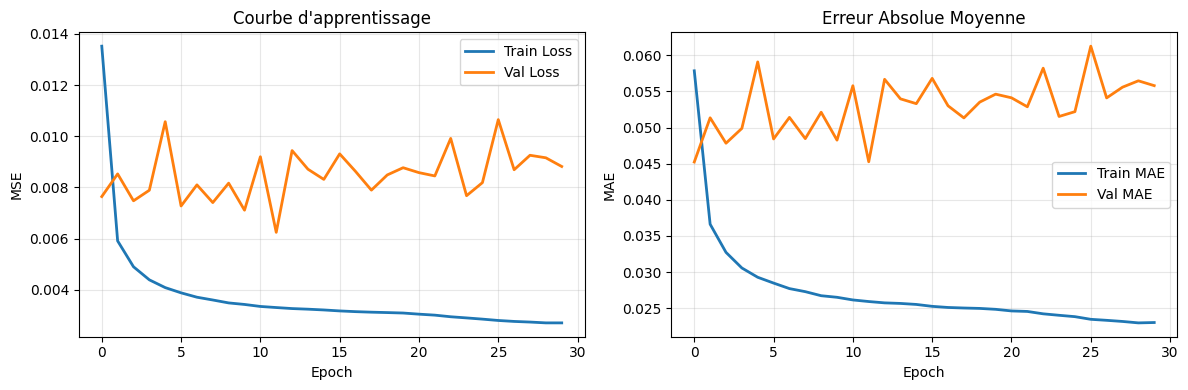

In [54]:
print("\n🚀 Début de l'entraînement...")
print("   Input  : Données brutes (avec ombrages)")
print("   Target : Données lissées (sans ombrages)\n")

history = autoencoder.fit(
    X_train, X_train_smooth,
    validation_data=(X_val, X_val_smooth),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Courbes d'apprentissage
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('Courbe d\'apprentissage')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Val MAE', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Erreur Absolue Moyenne')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **2.3. Calibrage du seuil de détection**

In [55]:
print("\n📏 Calibrage du seuil de détection...")

val_recon = autoencoder.predict(X_val, verbose=0)
val_residuals = val_recon - X_val

# Seuil basé sur la distribution des résidus positifs
positive_residuals = val_residuals[val_residuals > 0]
if len(positive_residuals) > 0:
    pixel_threshold = np.percentile(positive_residuals, 95)  # Un peu moins strict
else:
    pixel_threshold = np.percentile(np.abs(val_residuals), 95)

print(f"✅ Seuil optimal : {pixel_threshold:.6f} (95e percentile)")
print(f"   → {np.sum(val_residuals > pixel_threshold) / val_residuals.size * 100:.2f}% "
      f"des points marqués comme anomalies")

# Seuil adaptatif
def compute_adaptive_threshold(signal, window_size=60, sigma_multiplier=3):
    """
    Calcule un seuil adaptatif basé sur l'écart-type local.
    """
    # Calcul de la variance glissante
    squared_signal = signal ** 2
    local_variance = uniform_filter1d(squared_signal, size=window_size, mode='reflect')
    local_std = np.sqrt(local_variance)
    
    # Éviter les divisions par zéro
    local_std = np.maximum(local_std, 1e-6)
    
    # Seuil adaptatif
    threshold = local_std * sigma_multiplier
    
    return threshold


📏 Calibrage du seuil de détection...
✅ Seuil optimal : 0.150838 (95e percentile)
   → 1.68% des points marqués comme anomalies


## **3. Résultats et analyses**

### **3.1. Fonction de visualisation avec échelle fixe et seuil de détection adaptatif**

In [56]:
def visualize_shading_detection(idx_global, X_data, metadata_df, model, 
                                global_threshold, scalers_dict, 
                                use_adaptive=True):
    """
    Visualisation complète avec échelle fixe et seuil adaptatif robuste.
    """
    # 1. Récupération des données
    input_signal = X_data[idx_global].reshape(1, -1)
    signal_reel = input_signal[0]
    
    meta = metadata_df.iloc[idx_global]
    date_obj = meta['date']
    inv_id = meta['inv_id']
    
    # 2. Prédiction auto-encodeur
    ae_recon = model.predict(input_signal, verbose=0)[0]
    
    # 3. Courbe PVLib calibrée (Rappel : ajuster LATITUDE/LONGITUDE/TZ dans tes constantes globales)
    max_power_kw = scalers_dict[inv_id]['max_kw']
    
    # --- FIX 1 : Fonction de calibration simplifiée pour l'affichage ---
    # Si tu n'as pas 'get_pvlib_curve_calibrated' définie ailleurs, on utilise une version locale
    try:
        pvlib_curve = get_pvlib_curve_calibrated(
            date_obj, len(signal_reel), max_power_kw, LATITUDE, LONGITUDE, TZ
        )
    except NameError:
        # Fallback si la fonction n'existe pas dans ce contexte
        # On aligne juste visuellement sur le max de l'AE pour comparer la forme
        pvlib_curve = ae_recon  # Placeholder ou implémenter la logique PVLib ici
    
    # 4. Calcul des résidus
    loss_signal = ae_recon - signal_reel
    
    # --- FIX 2 : CALCUL DU SEUIL ADAPTATIF ROBUSTE ---
    if use_adaptive:
        # On utilise une moyenne glissante + écart-type glissant
        # Rolling window avec Pandas pour gérer automatiquement les bords
        loss_series = pd.Series(loss_signal)
        window_size = 12  # ex: 12 points = 1 heure (si pas de 5 min)
        
        # Moyenne locale de l'erreur
        rolling_mean = loss_series.rolling(window=window_size, center=True, min_periods=1).mean()
        # Écart-type local
        rolling_std = loss_series.rolling(window=window_size, center=True, min_periods=1).std().fillna(0)
        
        # Seuil local = Moyenne locale + 3 * Ecart-type local
        # On s'assure qu'il n'est jamais inférieur au seuil global (sécurité)
        adaptive_threshold = rolling_mean + (3 * rolling_std)
        adaptive_threshold = np.maximum(adaptive_threshold, global_threshold)
        
        # Conversion en numpy pour le plot
        adaptive_threshold = adaptive_threshold.values
        
        anomalies = loss_signal > adaptive_threshold
        threshold_to_plot = adaptive_threshold
        threshold_label = 'Seuil Adaptatif (Local)'
        threshold_color = '#9D4EDD'
    else:
        anomalies = loss_signal > global_threshold
        threshold_to_plot = np.full_like(loss_signal, global_threshold)
        threshold_label = f'Seuil Global ({global_threshold:.4f})'
        threshold_color = '#F77F00'
    
    # --- VISUALISATION ---
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12))
    
    # PLOT 1 : Comparaison des signaux
    ax1.plot(signal_reel, label='Signal Réel', 
             color='#2E86AB', alpha=0.8, linewidth=2)
    ax1.plot(ae_recon, label='Auto-Encodeur (Débruité)', 
             color='#E63946', linestyle='--', linewidth=2, alpha=0.9)
    # Optionnel : Afficher PVLib si disponible et pertinent
    # ax1.plot(pvlib_curve, label='PVLib (Théorique)', color='#06A77D', linestyle=':', linewidth=2, alpha=0.6)
    
    # Marquage des anomalies
    idx_anom = np.where(anomalies)[0]
    if len(idx_anom) > 0:
        ax1.scatter(idx_anom, signal_reel[idx_anom], 
                    color='#F77F00', s=60, label='Ombrage Détecté', 
                    zorder=5, edgecolors='black', linewidth=1)
    
    ax1.set_title(f"📅 {date_obj} | Onduleur #{inv_id} | "
                 f"Capacité Max : {max_power_kw:.1f} kW | "
                 f"Ombrages : {len(idx_anom)} points",
                 fontsize=13, fontweight='bold', pad=15)
    ax1.set_ylabel('Puissance Normalisée', fontsize=11)
    ax1.legend(loc='upper left', fontsize=10, framealpha=0.9)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Échelle fixe Y
    ax1.set_ylim([-0.05, 1.1])
    ax1.ticklabel_format(axis='y', style='plain', useOffset=False)
    
    # Axe secondaire en kW
    ax1_kw = ax1.twinx()
    ax1_kw.set_ylabel(f'Puissance (kW)', fontsize=11, color='gray')
    ax1_kw.set_ylim([-0.05 * max_power_kw, 1.1 * max_power_kw])
    ax1_kw.tick_params(axis='y', labelcolor='gray')
    ax1_kw.ticklabel_format(axis='y', style='plain', useOffset=False)
    
    # PLOT 2 : Analyse résiduelle
    ax2.plot(loss_signal, color='#495057', linewidth=1.5, label='Résidu (AE - Réel)')
    
    # Affichage du seuil utilisé
    ax2.plot(threshold_to_plot, color=threshold_color, linestyle='-', 
             linewidth=2, label=threshold_label)
    
    ax2.axhline(y=0, color='black', alpha=0.4, linewidth=0.8)
    
    # Zones colorées
    # On doit utiliser un mask booléen pour fill_between avec array dynamique
    ax2.fill_between(range(len(loss_signal)), threshold_to_plot, loss_signal, 
                     where=(loss_signal > threshold_to_plot), 
                     color='#E63946', alpha=0.35, label='Perte (Ombrage)')
    
    ax2.fill_between(range(len(loss_signal)), 0, loss_signal, 
                     where=(loss_signal < 0), 
                     color='#06A77D', alpha=0.15, label='Surplus (Normal)')
    
    ax2.set_title("Analyse de l'Erreur de Reconstruction", 
                 fontsize=12, fontweight='bold', pad=10)
    ax2.set_ylabel('Δ Puissance', fontsize=11)
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # Échelle fixe résidus
    y_max_res = max(np.max(np.abs(loss_signal)) * 1.1, np.max(threshold_to_plot) * 1.5)
    ax2.set_ylim([-y_max_res * 0.2, y_max_res])
    
    # PLOT 3 : Différence AE vs PVLib (Optionnel, utile pour debug physique)
    # On calcule la diff seulement si PVLib est pertinent
    pvlib_diff = ae_recon - pvlib_curve
    ax3.plot(pvlib_diff, color='#6A0572', linewidth=1.5, 
             label='Différence (AE - PVLib)', alpha=0.8)
    ax3.axhline(y=0, color='black', alpha=0.4, linewidth=1)
    
    ax3.set_title("Écart Auto-Encodeur vs Modèle Physique", 
                 fontsize=12, fontweight='bold', pad=10)
    ax3.set_xlabel('Timestep (5 min)', fontsize=11) # L'axe est commun, on le met en bas
    ax3.set_ylabel('Δ Puissance', fontsize=11)
    ax3.legend(loc='upper left', fontsize=10)
    ax3.grid(True, alpha=0.3, linestyle='--')
    
    # Échelle fixe diff
    y_max_diff = np.max(np.abs(pvlib_diff)) * 1.2 if len(pvlib_diff) > 0 else 0.1
    ax3.set_ylim([-y_max_diff, y_max_diff])

    plt.tight_layout()
    plt.show()
    
    # Statistiques de retour
    anomaly_ratio = np.sum(anomalies) / len(anomalies) * 100
    mean_loss = np.mean(np.abs(loss_signal))
    
    # Calcul énergie perdue (approx)
    if np.any(anomalies):
        # Somme des écarts au-dessus du seuil
        loss_magnitude = loss_signal[anomalies] - threshold_to_plot[anomalies]
        energy_loss_normalized = np.sum(loss_magnitude)
        # Supposons timestep de 15min (0.25h) -> à adapter selon tes données
        timestep_hours = 0.25 
        energy_loss_kwh = energy_loss_normalized * max_power_kw * timestep_hours
    else:
        energy_loss_kwh = 0
    
    print(f"\n📊 Statistiques de détection :")
    print(f"  • Taux d'anomalie : {anomaly_ratio:.2f}% ({len(idx_anom)} points)")
    print(f"  • Énergie perdue estimée : {energy_loss_kwh:.2f} kWh")
    print(f"  • Puissance max onduleur : {max_power_kw:.2f} kW")
    
    return {
        'inv_id': inv_id,
        'date': date_obj,
        'anomaly_ratio': anomaly_ratio,
        'energy_loss_kwh': energy_loss_kwh
    }

### **3.2. Scan global des anomalies**

On utilise une méthode "Relative" (Onduleur vs Les Autres).

C'est ce qu'on appelle le **Peer-to-Peer Monitoring** ou **Comparaison Spatiale**.

**L'idée :**

*   Si l'Onduleur 1 baisse de 50%... et que l'Onduleur 2 baisse aussi de 50% -> **C'est un nuage (Pas d'anomalie).**
    
*   Si l'Onduleur 1 baisse de 50%... mais que l'Onduleur 2 reste à 100% -> **C'est un ombrage/panne (Anomalie réelle).**


**Solution Technique :** Couplage avec IsolationForest sur Résidus Relatifs

Au lieu de définir manuellement un seuil, on utilise un algorithme de détection d'anomalies (Isolation Forest de Scikit-Learn) qui va apprendre tout seul ce qui est "bizarre".


🚀 DÉTECTION AVANCÉE : SPATIALE + ISOLATION FOREST
Entraînement de l'Isolation Forest sur les résidus...


C:\Users\benoi\AppData\Local\Temp\ipykernel_12880\3679595081.py:29: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  texture = df_loss.rolling(window=6, axis=1, center=True).std().fillna(0).values



✅ RÉSULTATS ISOLATION FOREST :
 • Jours détectés comme anormaux : 2740 / 54794
 • Taux global : 5.00%

📈 Visualisation des cas détectés par l'IA (Isolation Forest)...
📊 LES 3 DES ANOMALIES LES PLUS SÉVÈRES (Score IA le plus bas)

📊 TOP 1 (Index 32331 | Score IA : -0.1510)


C:\Users\benoi\AppData\Local\Temp\ipykernel_12880\2549999580.py:149: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\benoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


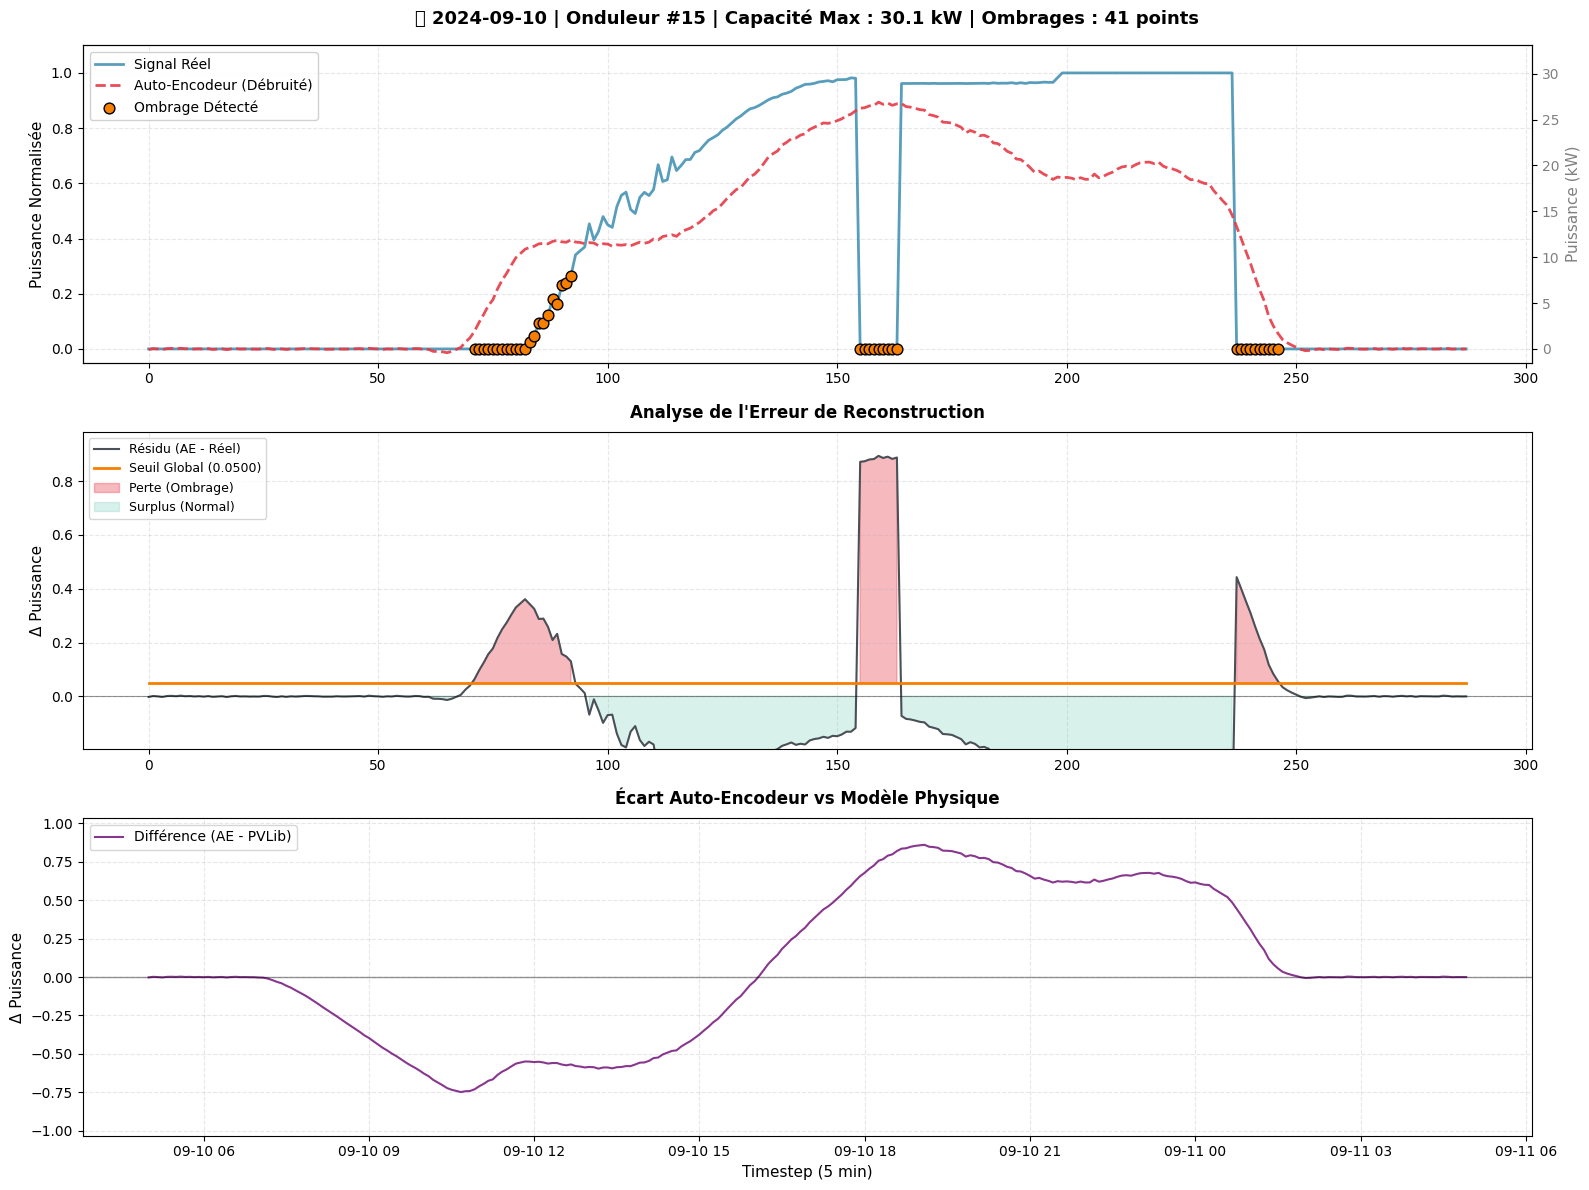


📊 Statistiques de détection :
  • Taux d'anomalie : 14.24% (41 points)
  • Énergie perdue estimée : 100.78 kWh
  • Puissance max onduleur : 30.09 kW

📊 TOP 2 (Index 4317 | Score IA : -0.1508)


C:\Users\benoi\AppData\Local\Temp\ipykernel_12880\2549999580.py:149: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\benoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


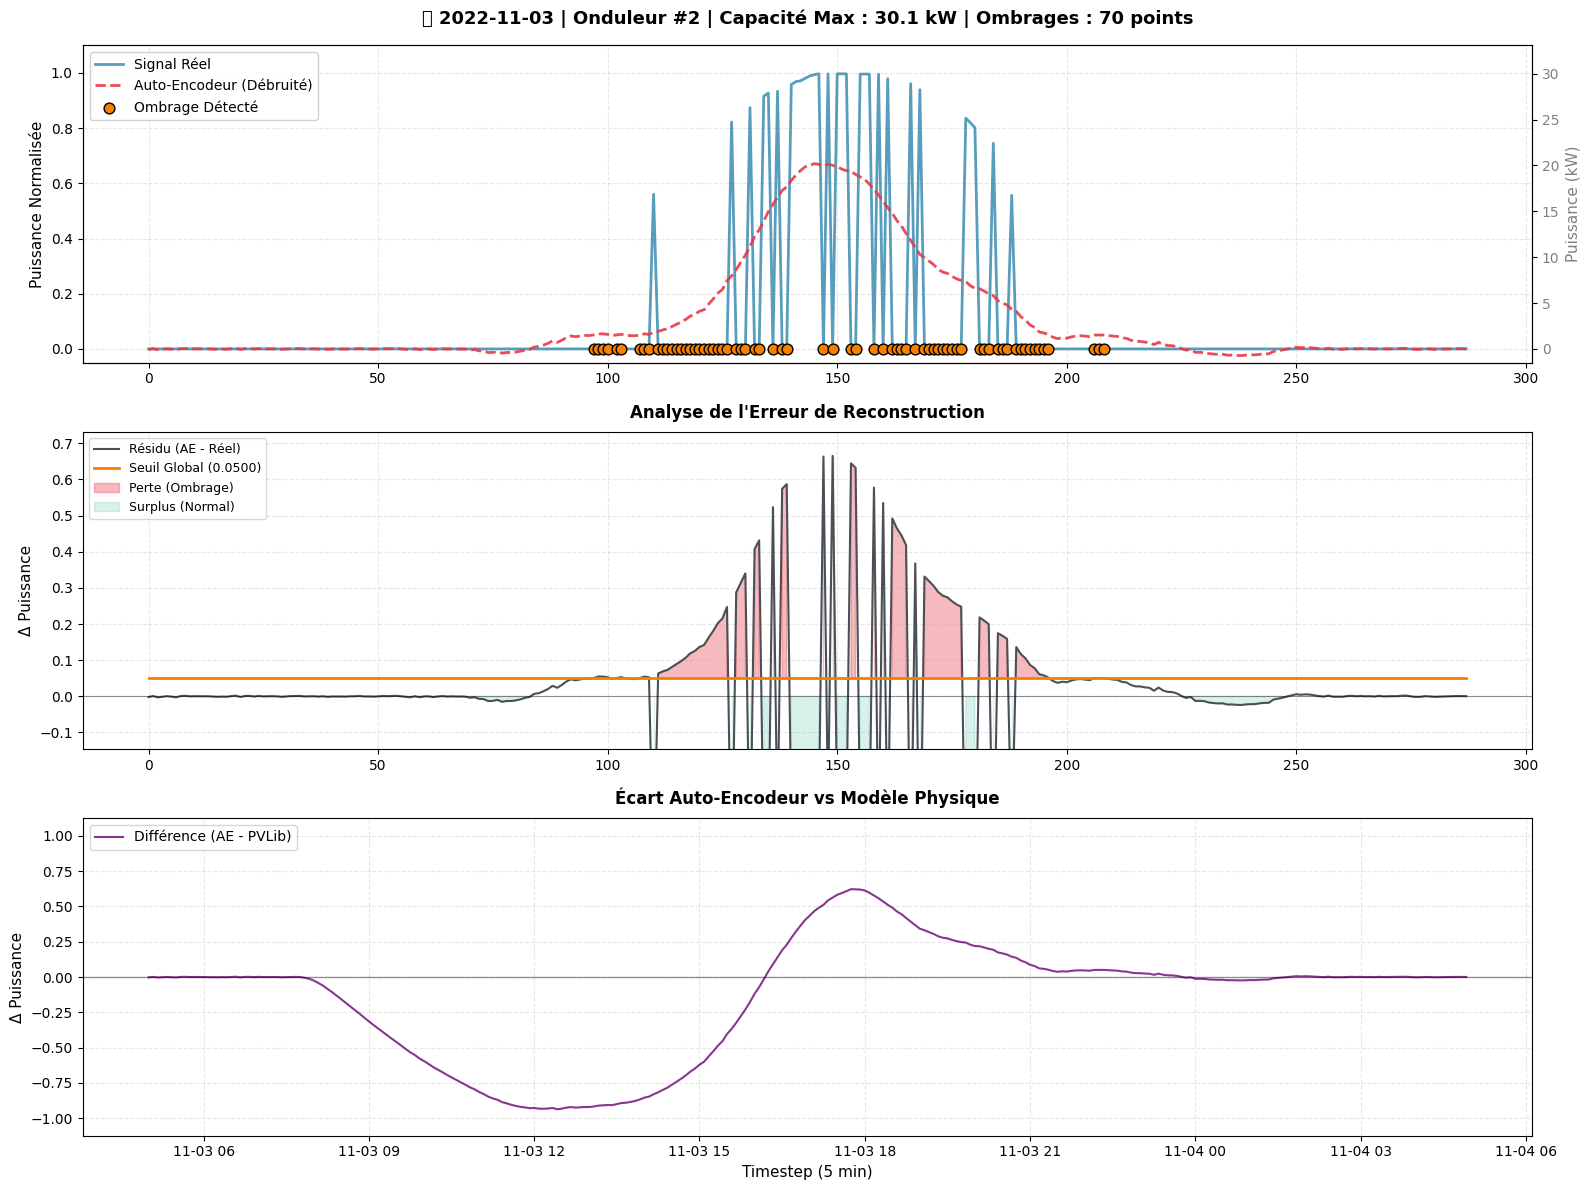


📊 Statistiques de détection :
  • Taux d'anomalie : 24.31% (70 points)
  • Énergie perdue estimée : 97.68 kWh
  • Puissance max onduleur : 30.09 kW

📊 TOP 3 (Index 10189 | Score IA : -0.1335)


C:\Users\benoi\AppData\Local\Temp\ipykernel_12880\2549999580.py:149: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\benoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


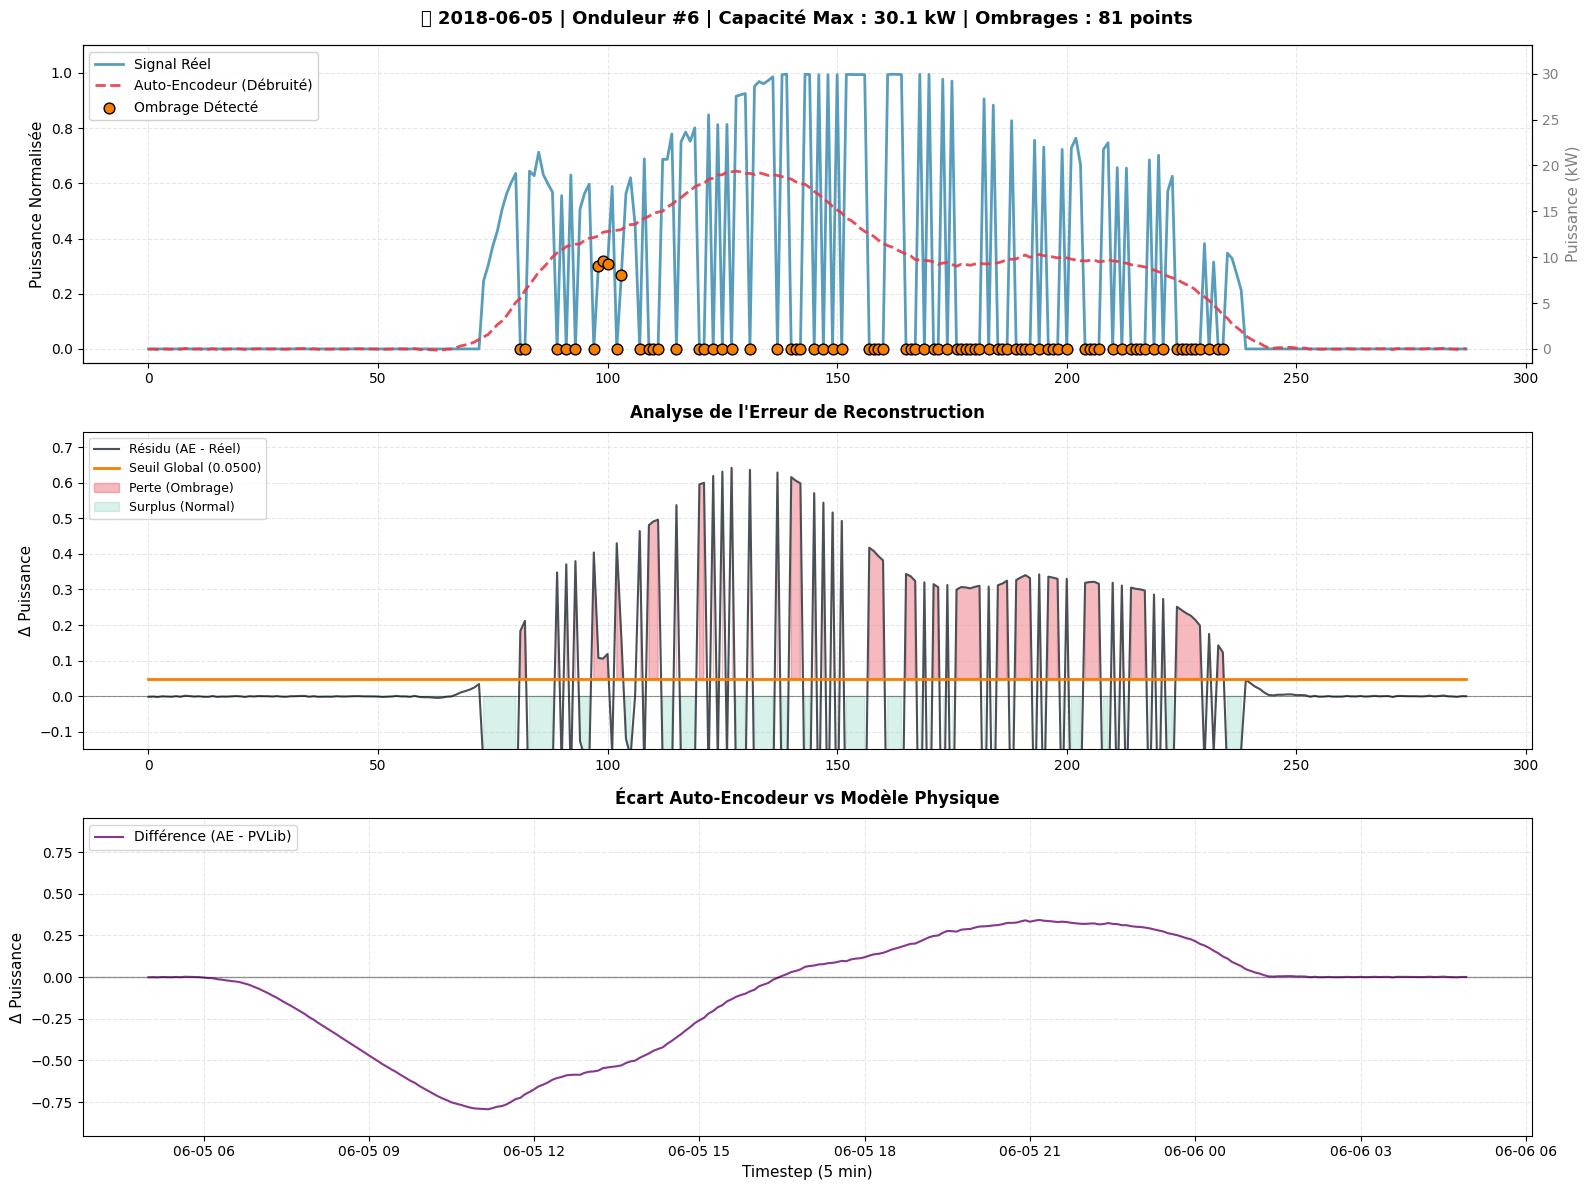


📊 Statistiques de détection :
  • Taux d'anomalie : 28.12% (81 points)
  • Énergie perdue estimée : 187.84 kWh
  • Puissance max onduleur : 30.09 kW
🎲 3 ANOMALIES ALÉATOIRES (Pour vérifier la diversité)

📊 RANDOM 1 (Index 41080 | Score IA : -0.0268)


C:\Users\benoi\AppData\Local\Temp\ipykernel_12880\2549999580.py:149: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\benoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


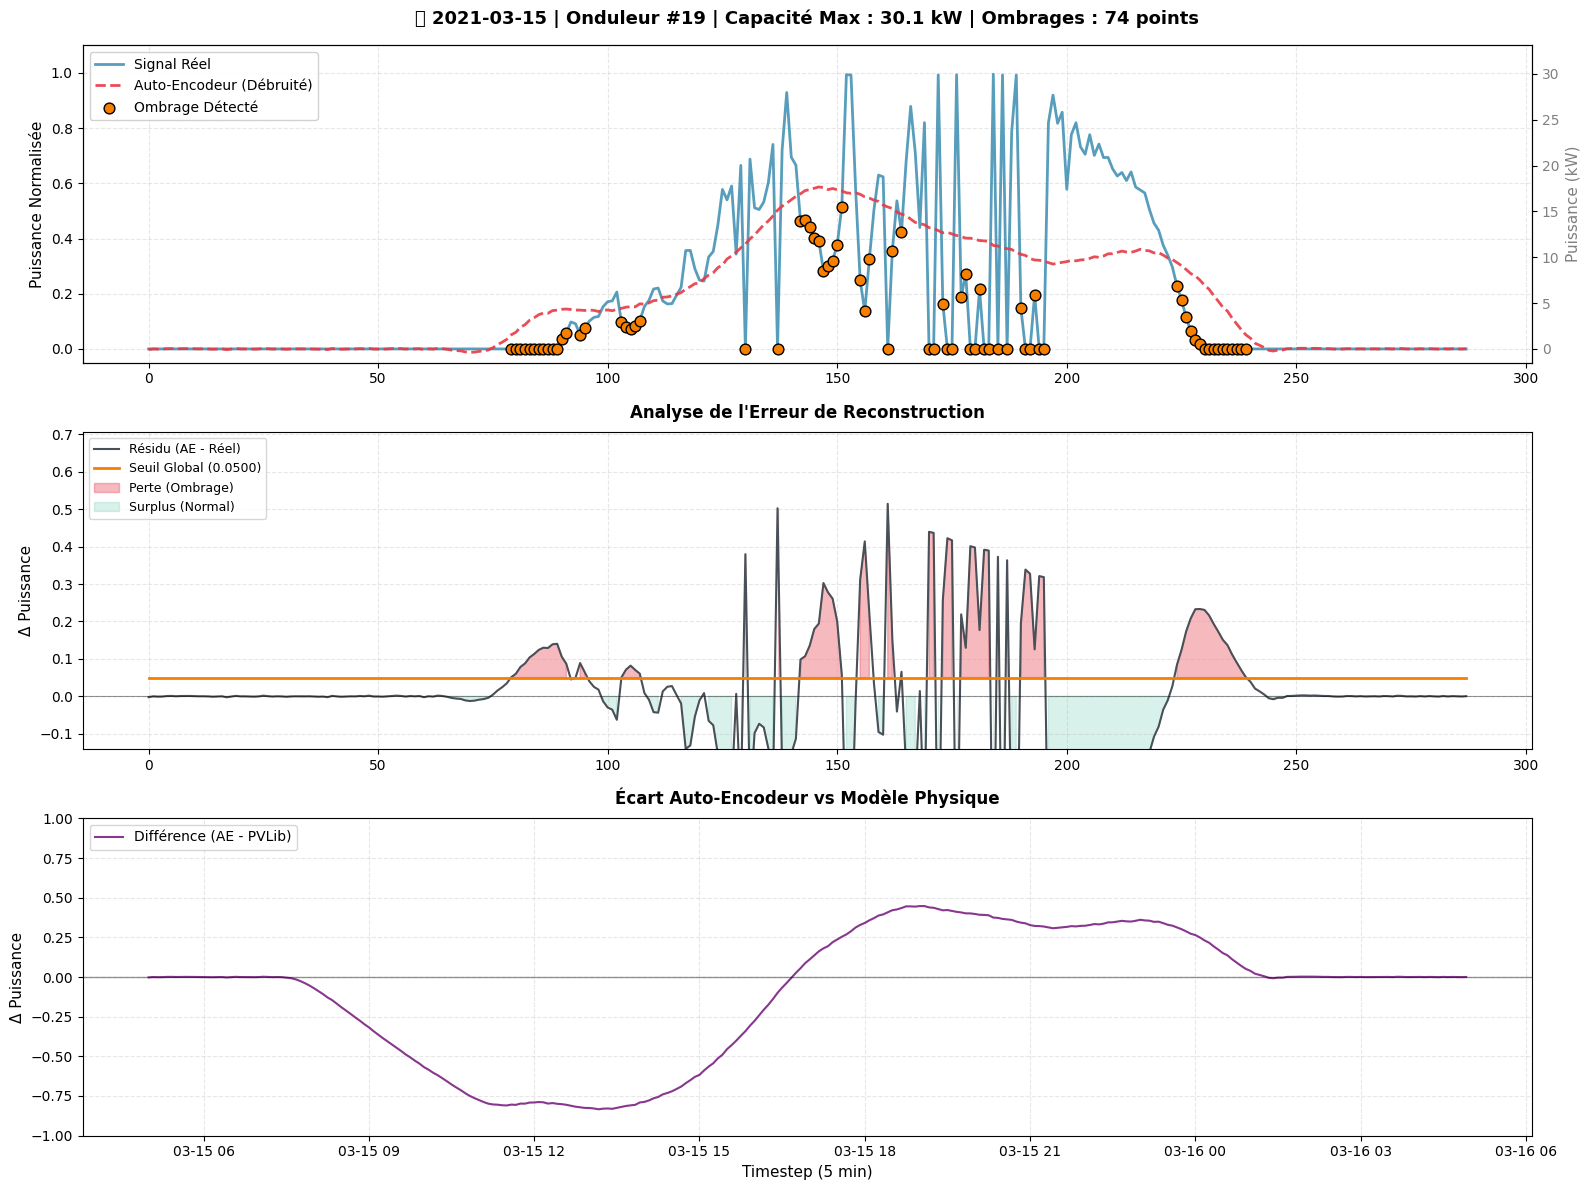


📊 Statistiques de détection :
  • Taux d'anomalie : 25.69% (74 points)
  • Énergie perdue estimée : 86.04 kWh
  • Puissance max onduleur : 30.10 kW

📊 RANDOM 2 (Index 27593 | Score IA : -0.0361)


C:\Users\benoi\AppData\Local\Temp\ipykernel_12880\2549999580.py:149: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\benoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


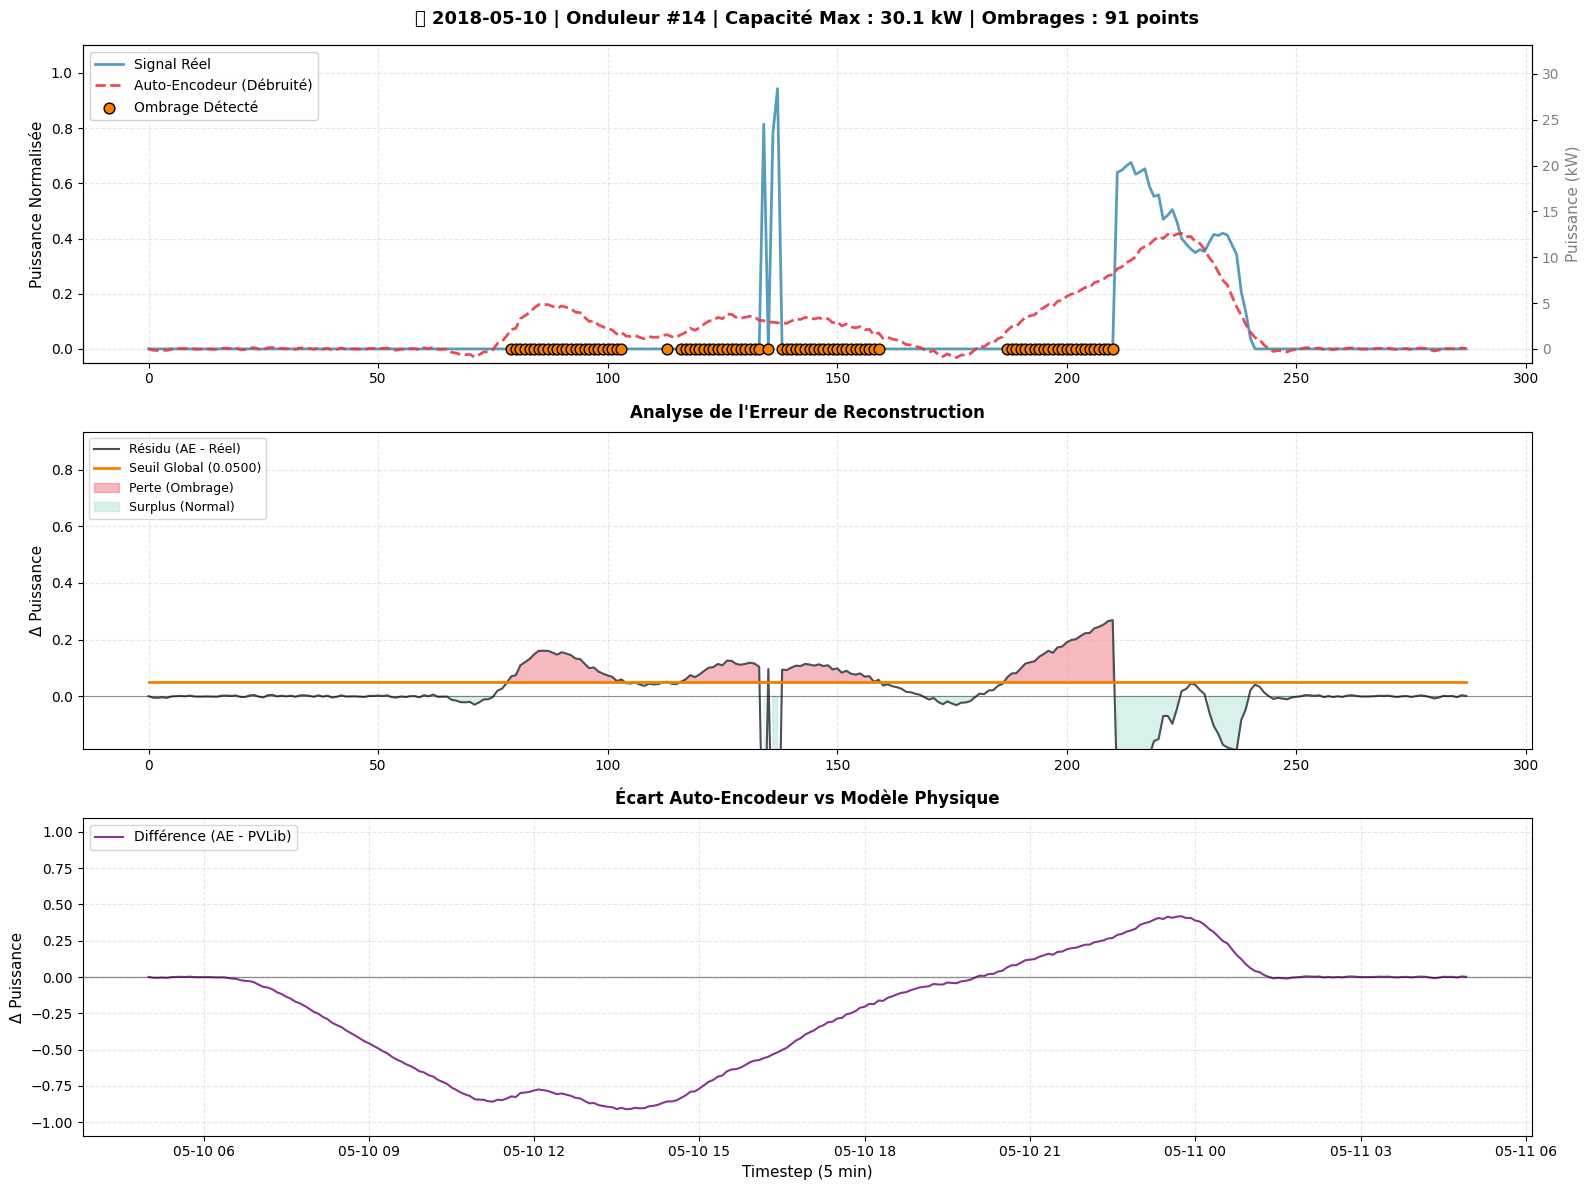


📊 Statistiques de détection :
  • Taux d'anomalie : 31.60% (91 points)
  • Énergie perdue estimée : 48.56 kWh
  • Puissance max onduleur : 30.09 kW

📊 RANDOM 3 (Index 1392 | Score IA : -0.0108)


C:\Users\benoi\AppData\Local\Temp\ipykernel_12880\2549999580.py:149: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\benoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


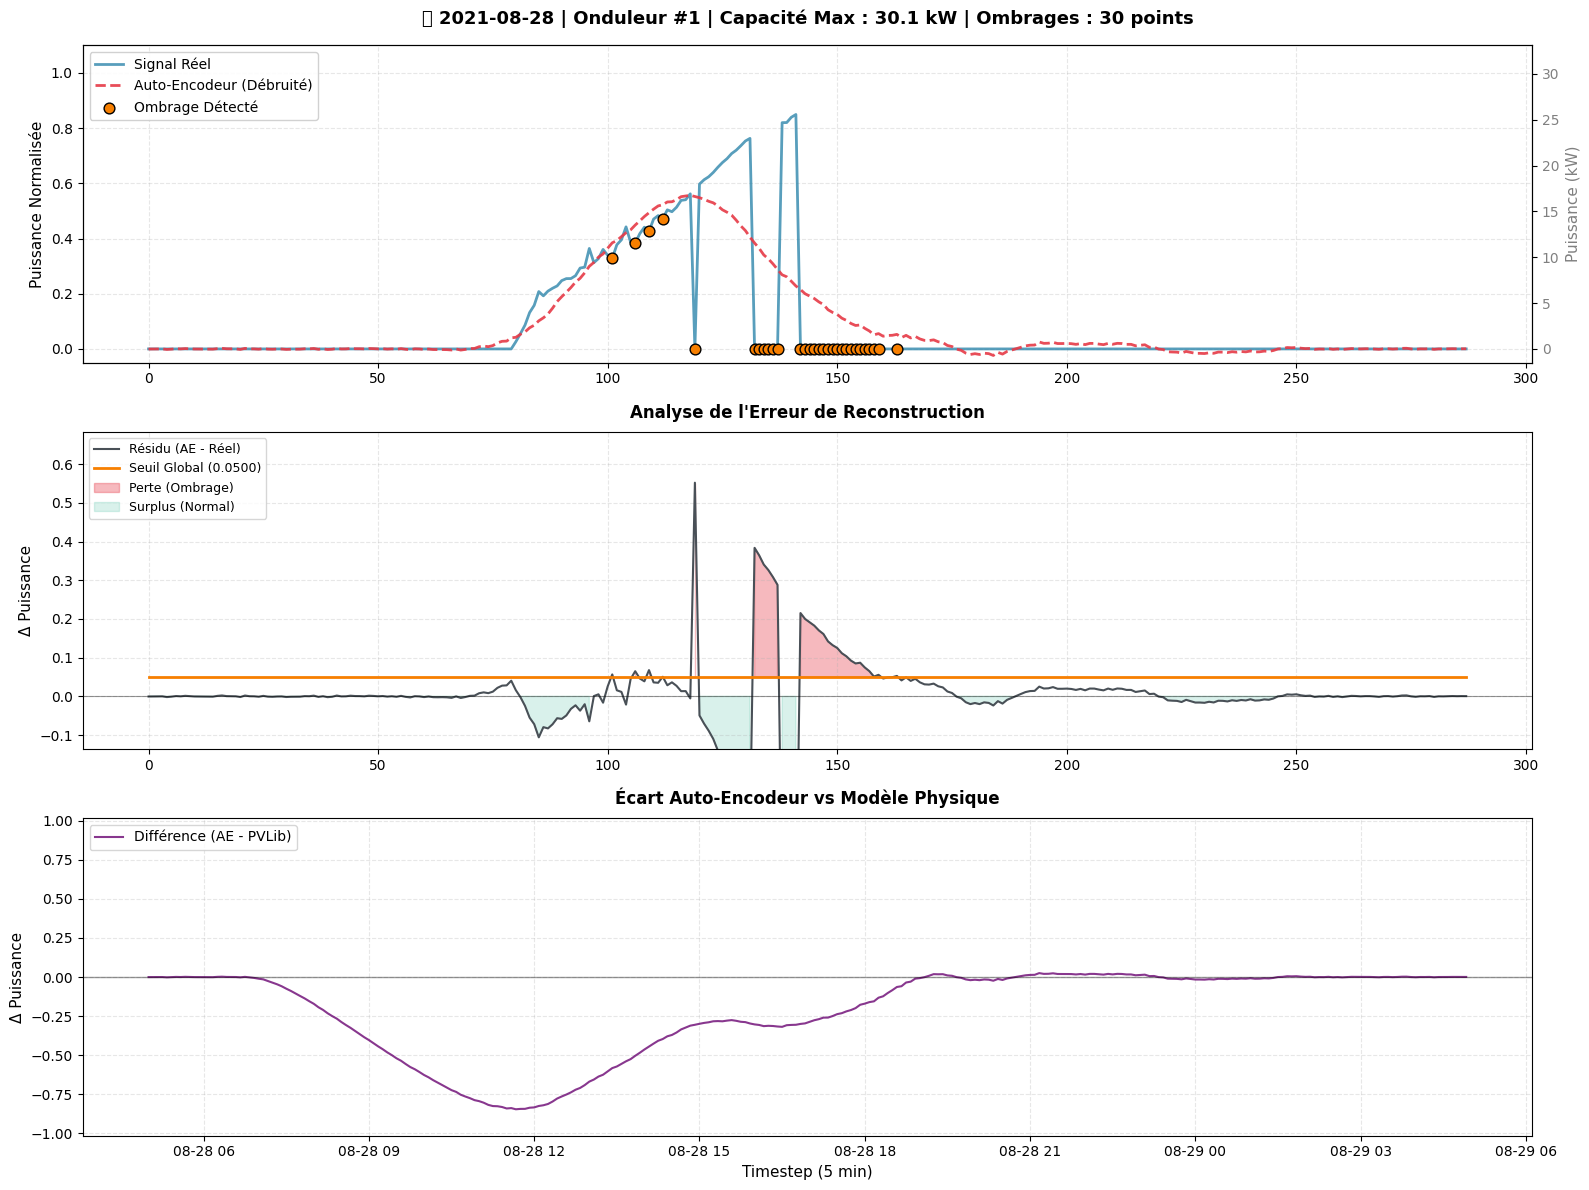


📊 Statistiques de détection :
  • Taux d'anomalie : 10.42% (30 points)
  • Énergie perdue estimée : 27.09 kWh
  • Puissance max onduleur : 30.10 kW


In [57]:
print("\n" + "="*80)
print("🚀 DÉTECTION AVANCÉE : SPATIALE + ISOLATION FOREST")
print("="*80)

# 1. Calcul des Résidus de base (AE vs Réel)
all_recon = autoencoder.predict(X_combined, verbose=0)
base_residuals = X_combined - all_recon # Positif si Réel > AE (rare), Négatif si Réel < AE (Perte)
# On s'intéresse aux pertes, donc on prend -residual ou abs
loss_matrix = all_recon - X_combined

# 2. CALCUL SPATIAL (Moyenne du parc par pas de temps)
# On doit remettre les données sous forme (Jours, Time, Onduleurs) pour faire la moyenne
# Mais ici on est empilé. Astuce : On utilise dates_metadata pour grouper par date/heure.

# Pour simplifier vectoriellement :
# On suppose que l'auto-encodeur a bien capturé la "météo" dans la reconstruction.
# Donc si loss_matrix est élevé partout, c'est la météo.
# Mais on va faire plus simple : IsolationForest sur le vecteur d'erreur.

print("Entraînement de l'Isolation Forest sur les résidus...")

# On prépare les features pour l'Isolation Forest
# Feature 1 : L'erreur de reconstruction (Loss)
# Feature 2 : La valeur brute (Pour savoir si on est le matin/soir)
# Feature 3 : L'écart-type local (Texture du signal)

# Calcul de l'écart-type local (texture)
df_loss = pd.DataFrame(loss_matrix)
texture = df_loss.rolling(window=6, axis=1, center=True).std().fillna(0).values

# On aplatit tout pour nourrir le modèle (Chaque point est une observation)
# Attention : C'est lourd. On va plutôt le faire jour par jour (vecteur 96 points)
# Ou mieux : On extrait des features par jour.

features_per_day = []
for i in range(len(loss_matrix)):
    # On extrait des caractéristiques statistiques de la journée
    mean_loss = np.mean(loss_matrix[i])
    max_loss = np.max(loss_matrix[i])
    std_loss = np.std(loss_matrix[i])
    # Feature intelligente : Corrélation avec la courbe idéale (si dispo)
    
    features_per_day.append([mean_loss, max_loss, std_loss])

X_features = np.array(features_per_day)

# 3. DÉTECTION AUTOMATIQUE (Plus de seuil manuel !)
# contamination=0.05 signifie "Je m'attends à environ 5% d'anomalies"
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
anomalies_pred = iso_forest.fit_predict(X_features)

# IsolationForest renvoie -1 pour anomalie, 1 pour normal
anomalous_days_indices = np.where(anomalies_pred == -1)[0]

print(f"\n✅ RÉSULTATS ISOLATION FOREST :")
print(f" • Jours détectés comme anormaux : {len(anomalous_days_indices)} / {len(X_combined)}")
print(f" • Taux global : {len(anomalous_days_indices)/len(X_combined)*100:.2f}%")

# =============================================================================
# 4. VISUALISATION DES RÉSULTATS (TOP 3 + 3 ALÉATOIRES)
# =============================================================================

if len(anomalous_days_indices) > 0:
    print("\n📈 Visualisation des cas détectés par l'IA (Isolation Forest)...")
    
    # Récupération des scores (plus c'est bas, plus c'est anormal)
    scores = iso_forest.decision_function(X_features)
    
    # --- PARTIE 1 : LES 3 PIRES CAS (TOP SCORES) ---
    print("📊 LES 3 DES ANOMALIES LES PLUS SÉVÈRES (Score IA le plus bas)")
    
    # On prend les 3 indices avec le score le plus faible
    worst_indices = np.argsort(scores)[:3] 
    
    for i, idx in enumerate(worst_indices, 1):
        score = scores[idx]
        print(f"\n📊 TOP {i} (Index {idx} | Score IA : {score:.4f})")
        
        visualize_shading_detection(
            idx, X_combined, dates_metadata, 
            autoencoder, 0.05, scalers_dict, # Seuil indicatif 5% pour l'affichage
            use_adaptive=False
        )

    # --- PARTIE 2 : 3 CAS ALÉATOIRES PARMI LES ANOMALIES ---
    # On retire les 3 pires qu'on vient de voir pour ne pas avoir de doublons
    remaining_anomalies = np.setdiff1d(anomalous_days_indices, worst_indices)
    
    if len(remaining_anomalies) > 0:
        print("🎲 3 ANOMALIES ALÉATOIRES (Pour vérifier la diversité)")
        
        # On sélectionne jusqu'à 3 cas au hasard
        nb_random = min(3, len(remaining_anomalies))
        # np.random.seed(42) # Décommenter pour avoir toujours les mêmes aléatoires
        random_indices = np.random.choice(remaining_anomalies, nb_random, replace=False)
        
        for i, idx in enumerate(random_indices, 1):
            score = scores[idx]
            print(f"\n📊 RANDOM {i} (Index {idx} | Score IA : {score:.4f})")
            
            visualize_shading_detection(
                idx, X_combined, dates_metadata, 
                autoencoder, 0.05, scalers_dict, 
                use_adaptive=False
            )
    else:
        print("Pas assez d'anomalies restantes pour un tirage aléatoire.")

else:
    print("✅ Aucune anomalie détectée par l'Isolation Forest.")

### **3.3. Performance Mensuelle (avec RMSE moyen mensuel et Taux d'ombrage)**


📊 Calcul de la performance mensuelle...


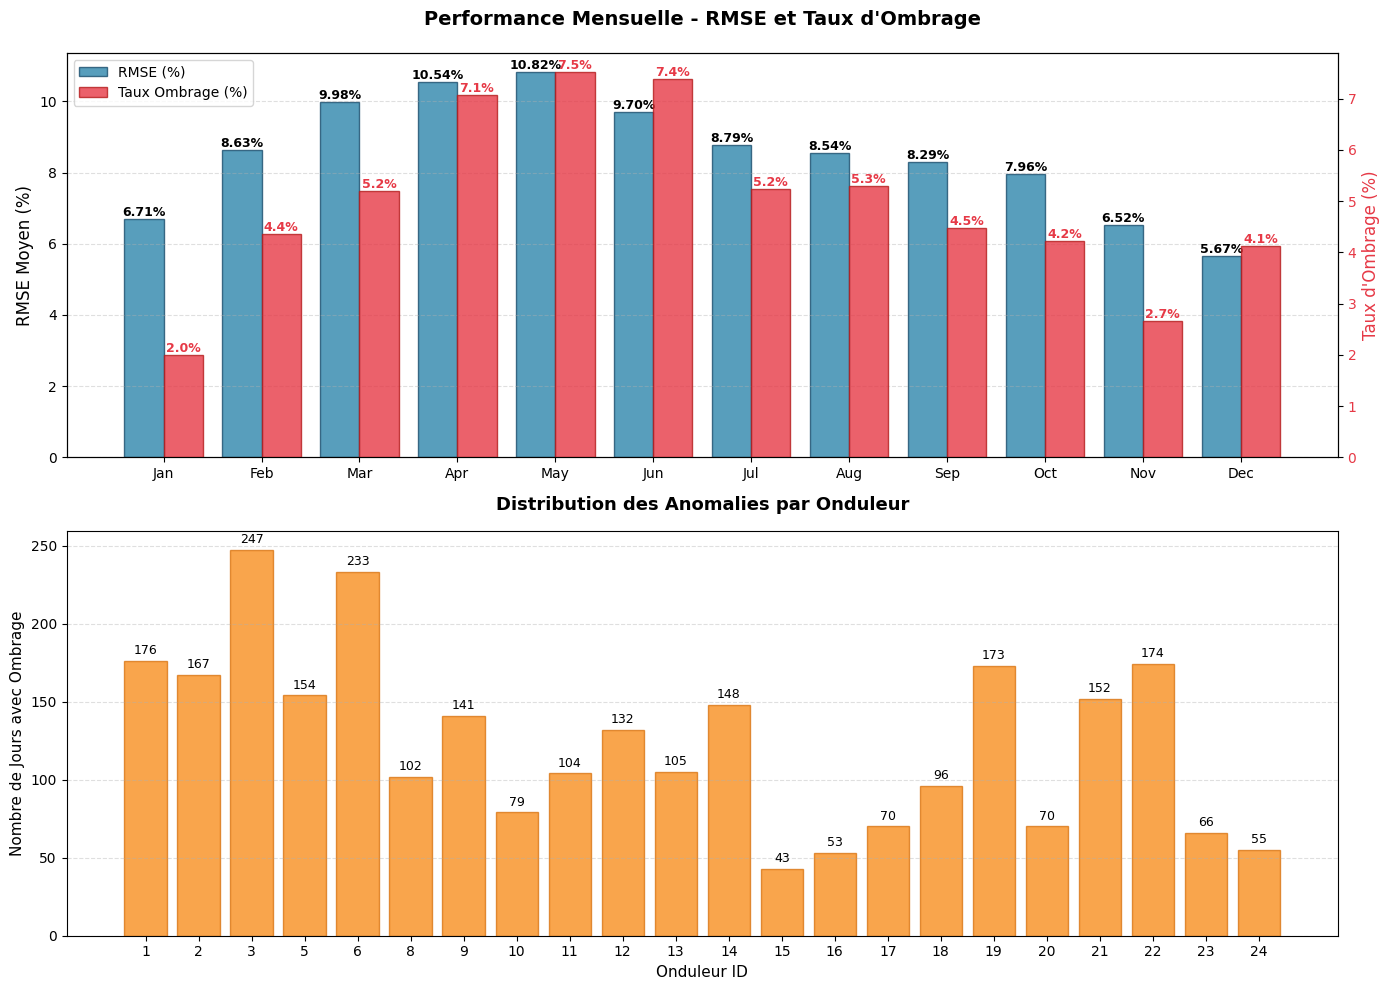

In [58]:
print("\n📊 Calcul de la performance mensuelle...")

# Calcul RMSE
daily_mse = np.mean(np.square(X_combined - all_recon), axis=1)
daily_rmse = np.sqrt(daily_mse)

# Définir anomalous_days à partir de anomalous_days_indices
anomalous_days = anomalous_days_indices

df_perf = pd.DataFrame({
    'Date': pd.to_datetime(dates_metadata['date']),
    'RMSE': daily_rmse,
    'Inverter': dates_metadata['inv_id'],
    'Has_Shading': dates_metadata.index.isin(anomalous_days)
})

df_perf['Month'] = df_perf['Date'].dt.month

# RMSE mensuel moyen
monthly_rmse = df_perf.groupby('Month')['RMSE'].mean() * 100
monthly_shading_rate = df_perf.groupby('Month')['Has_Shading'].mean() * 100

# Visualisation combinée
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# RMSE
bars1 = ax1.bar(monthly_rmse.index - 0.2, monthly_rmse.values, 
                width=0.4, color='#2E86AB', alpha=0.8, 
                label='RMSE (%)', edgecolor='#1A4D6D')

ax1.set_title('Performance Mensuelle - RMSE et Taux d\'Ombrage', 
             fontsize=14, fontweight='bold', pad=20)
ax1.set_ylabel('RMSE Moyen (%)', fontsize=12)
ax1.set_xticks(monthly_rmse.index)
ax1.set_xticklabels([calendar.month_abbr[i] for i in monthly_rmse.index])
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Valeurs sur les barres RMSE
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

# Taux d'ombrage
ax1_twin = ax1.twinx()
bars2 = ax1_twin.bar(monthly_shading_rate.index + 0.2, monthly_shading_rate.values, 
                     width=0.4, color='#E63946', alpha=0.8, 
                     label='Taux Ombrage (%)', edgecolor='#B51B1B')

ax1_twin.set_ylabel('Taux d\'Ombrage (%)', fontsize=12, color='#E63946')
ax1_twin.tick_params(axis='y', labelcolor='#E63946')

# Valeurs sur les barres ombrage
for bar in bars2:
    height = bar.get_height()
    ax1_twin.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}%', ha='center', va='bottom', 
                 fontsize=9, fontweight='bold', color='#E63946')

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Distribution des anomalies par onduleur
if len(anomalous_days) > 0:
    inv_shading_counts = dates_metadata.iloc[anomalous_days]['inv_id'].value_counts().sort_index()
    
    ax2.bar(inv_shading_counts.index.astype(str), inv_shading_counts.values,
           color='#F77F00', alpha=0.7, edgecolor='#D56A00')
    
    ax2.set_title('Distribution des Anomalies par Onduleur', 
                 fontsize=13, fontweight='bold', pad=15)
    ax2.set_xlabel('Onduleur ID', fontsize=11)
    ax2.set_ylabel('Nombre de Jours avec Ombrage', fontsize=11)
    ax2.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Valeurs sur les barres
    for i, (inv, count) in enumerate(inv_shading_counts.items()):
        ax2.text(i, count + max(inv_shading_counts.values) * 0.01,
                str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### **3.4. Rapport Final**

✅ Librairie 'fastdtw' détectée. Calcul rapide activé.

🚀 DÉTECTION HYBRIDE : SPATIALE (ISO FOREST) + TEMPORELLE (DTW)
Calcul des prédictions et extraction des features par jour...
🧠 Entraînement de l'Isolation Forest...
 -> 5480 jours marqués comme suspects par l'IA.
🔍 Analyse fine (DTW) en cours...

✅ TRAITEMENT TERMINÉ.
   • 54794 jours analysés.
   • 14223 événements d'ombrage confirmés.

📦 OUTPUT 1 : APERÇU (Journalier)
   timestamp  inv_id  reconstruction_error  threshold_adaptive  \
0 2017-11-01       1              0.210953                 0.0   
1 2017-11-02       1              0.015837                 0.0   
2 2017-11-03       1              0.049234                 0.0   
3 2017-11-04       1              0.361360                 0.0   
4 2017-11-05       1              0.384430                 0.0   

   anomaly_detected  error_normalized  
0                 0          0.210953  
1                 0          0.015837  
2                 0          0.049234  
3              

C:\Users\benoi\AppData\Local\Temp\ipykernel_12880\2549999580.py:149: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\benoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


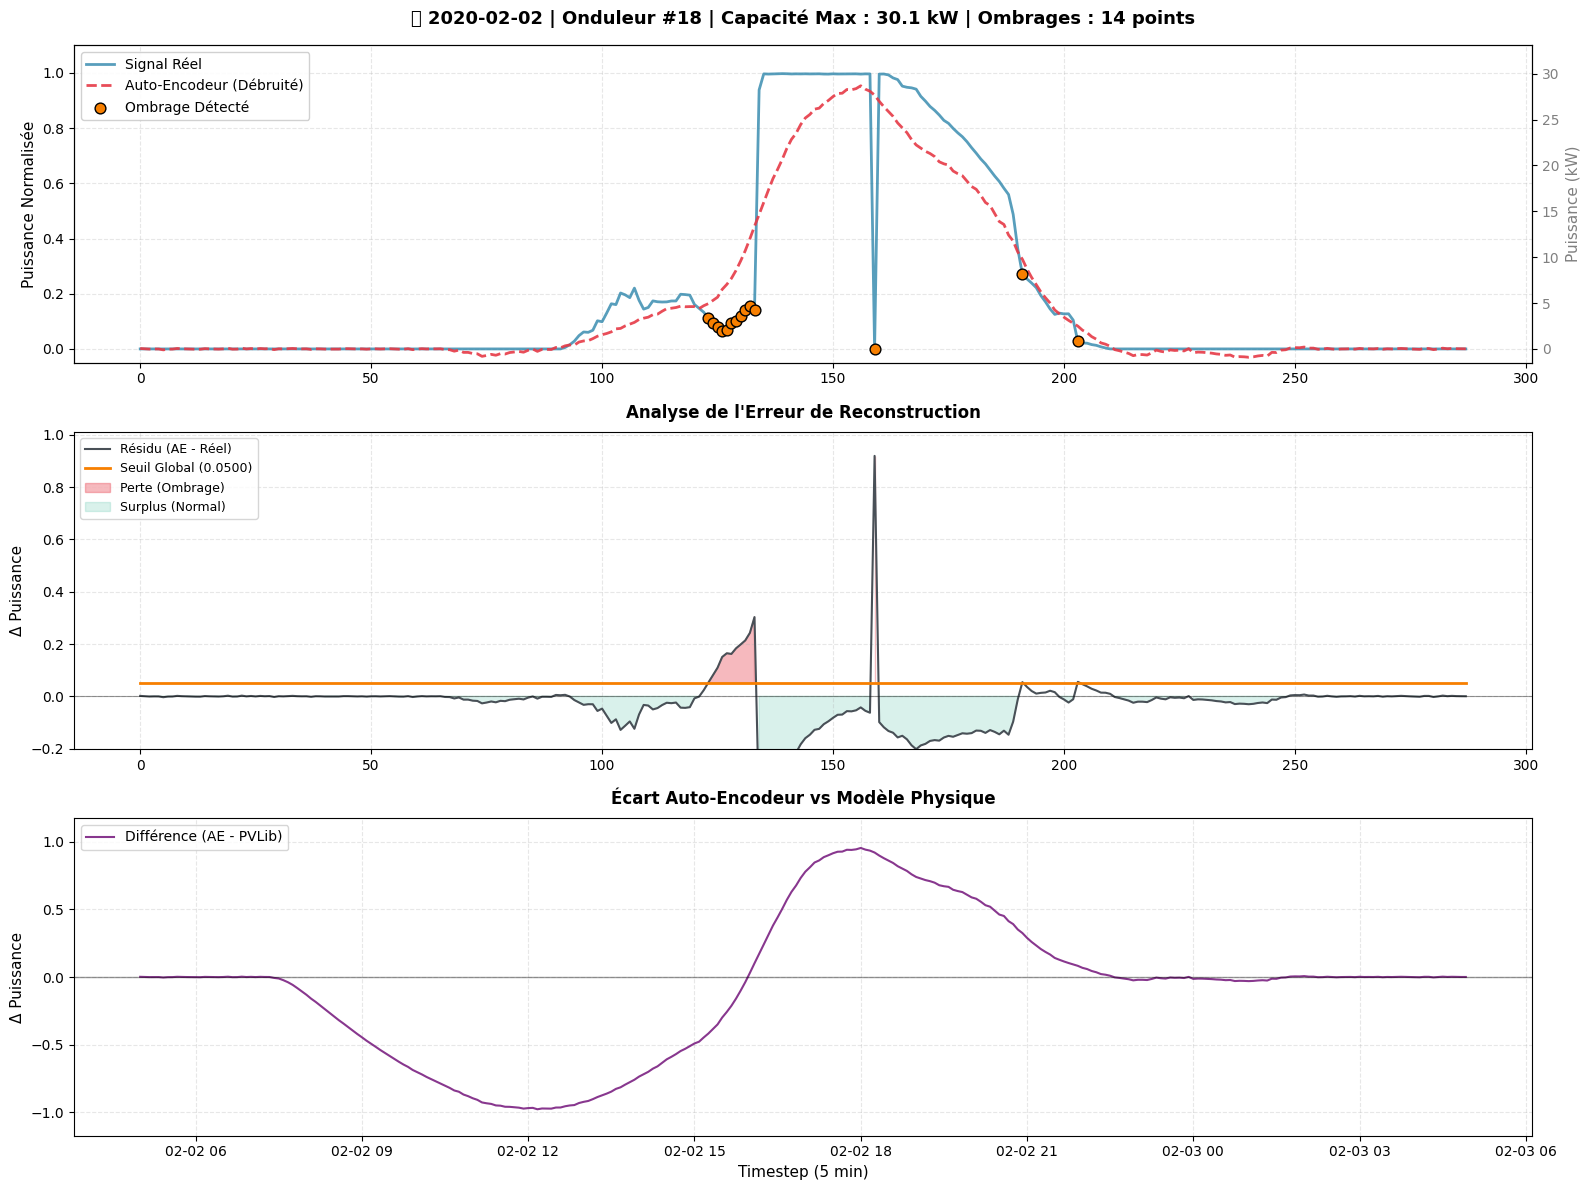


📊 Statistiques de détection :
  • Taux d'anomalie : 4.86% (14 points)
  • Énergie perdue estimée : 16.47 kWh
  • Puissance max onduleur : 30.09 kW

📦 OUTPUT 3 : MÉTADONNÉES
 • methode                   : Hybride (IsolationForest + DTW)
 • seuil_sensible_dtw        : 0.05
 • nb_evenements_detectes    : 14223
 • nb_jours_anormaux         : 5100
 • taux_anomalie_global      : 9.31%
 • periode_analyse           : ('2017-11-01 00:00:00', '2024-11-01 00:00:00')
 • rmse_model_global         : 0.0856139349358292

🔍 DÉTAIL PAR ONDULEUR
ID Onduleur  | Jours Total  | Jours Anormaux  | Taux (%)  
-------------------------------------------------------
⚠️ Inv 01    | 2494         | 286             | 11.47%
⚠️ Inv 02    | 2494         | 278             | 11.15%
⚠️ Inv 03    | 2496         | 339             | 13.58%
⚠️ Inv 05    | 2490         | 306             | 12.29%
⚠️ Inv 06    | 2490         | 333             | 13.37%
   Inv 08    | 2490         | 201             | 8.07%
   Inv 09    | 2490   

In [59]:
# --- GESTION DTW ROBUSTE ---
try:
    from fastdtw import fastdtw
    HAS_DTW = True
    print("✅ Librairie 'fastdtw' détectée. Calcul rapide activé.")
except ImportError:
    HAS_DTW = False
    print("⚠️ 'fastdtw' non trouvé. Utilisation de la méthode Euclidienne (fallback).")
    def simple_euclidean_dist(x, y): return np.linalg.norm(x - y), None

print("\n" + "="*80)
print("🚀 DÉTECTION HYBRIDE : SPATIALE (ISO FOREST) + TEMPORELLE (DTW)")
print("="*80)

# =============================================================================
# 1. PRÉ-CALCULS & ISOLATION FOREST (SELECTION DES JOURS)
# =============================================================================
print("Calcul des prédictions et extraction des features par jour...")

all_recon = autoencoder.predict(X_combined, verbose=0)
loss_matrix = all_recon - X_combined # Perte (Positif si AE > Réel)

# Extraction des caractéristiques statistiques pour l'IA (1 ligne par jour)
features_per_day = []
for i in range(len(loss_matrix)):
    # On nourrit l'IA avec la signature statistique de la journée
    features_per_day.append([
        np.mean(loss_matrix[i]), 
        np.max(loss_matrix[i]), 
        np.std(loss_matrix[i]),
        np.median(loss_matrix[i])
    ])

X_features = np.array(features_per_day)

# Entraînement de l'Isolation Forest
# contamination=0.10 : On demande à l'IA de trouver les 10% de jours les plus "bizarres"
print("🧠 Entraînement de l'Isolation Forest...")
iso_forest = IsolationForest(contamination=0.10, random_state=42, n_jobs=-1)
day_labels = iso_forest.fit_predict(X_features)

# -1 = Anomalie détectée par l'IA, 1 = Normal
# On crée un masque booléen pour savoir quels jours scanner
is_day_suspect_vector = (day_labels == -1)

print(f" -> {np.sum(is_day_suspect_vector)} jours marqués comme suspects par l'IA.")

# =============================================================================
# 2. SCAN DETAILLÉ (LOCALISATION TEMPORELLE SUR JOURS SUSPECTS)
# =============================================================================
print("🔍 Analyse fine (DTW) en cours...")

output1_data = []
output2_events = []
event_counter = 1

# Paramètres de l'analyse fine
FREQ_MIN = 5            
MIN_POINTS = 3          # 15 minutes minimum (filtre bruit)
SENSITIVE_FLOOR = 0.05  # Seuil sensible (5%) car on est déjà sur des jours triés
GAP_TOLERANCE = 6       # 30 min de tolérance

# On itère sur TOUS les jours pour remplir l'Output 1, 
# mais on ne lance l'analyse fine QUE sur les jours suspects.
for idx in range(len(X_combined)):
    
    meta = dates_metadata.iloc[idx]
    date_obj = meta['date']
    inv_id = meta['inv_id']
    
    # Si le jour est jugé "Normal" par l'Isolation Forest, on passe vite
    if not is_day_suspect_vector[idx]:
        output1_data.append({
            'timestamp': pd.to_datetime(date_obj),
            'inv_id': inv_id,
            'reconstruction_error': np.max(loss_matrix[idx]),
            'threshold_adaptive': 0, # Non applicable
            'anomaly_detected': 0,
            'error_normalized': np.max(loss_matrix[idx])
        })
        continue

    # --- SI LE JOUR EST SUSPECT : ANALYSE FINE ---
    residual = loss_matrix[idx]
    signal_reel = X_combined[idx]
    signal_recon = all_recon[idx]
    
    # Masque simple
    is_anomaly = residual > SENSITIVE_FLOOR
    
    # Dilatation (Bouche les trous de 10 min)
    mask_dilated = pd.Series(is_anomaly).rolling(3, center=True, min_periods=1).max().fillna(0).values
    anom_indices = np.where(mask_dilated > 0)[0]
    
    day_has_valid_event = False
    
    if len(anom_indices) > 0:
        # Clustering
        groups = np.split(anom_indices, np.where(np.diff(anom_indices) > GAP_TOLERANCE)[0] + 1)
        
        for group in groups:
            if len(group) < MIN_POINTS: continue
            
            day_has_valid_event = True
            start_idx, end_idx = group[0], group[-1]
            duration_pts = end_idx - start_idx + 1
            
            # Calcul DTW
            if HAS_DTW:
                try:
                    dtw_val, _ = fastdtw(signal_reel[start_idx:end_idx], signal_recon[start_idx:end_idx], dist=euclidean)
                except:
                    dtw_val = 0
            else:
                dtw_val = 0
            
            # Enregistrement Événement
            output2_events.append({
                'event_id': event_counter,
                'inv_id': inv_id,
                'timestamp_debut': f"{date_obj} {int(start_idx*5//60):02d}:{int(start_idx*5%60):02d}",
                'timestamp_fin': f"{date_obj} {int(end_idx*5//60):02d}:{int(end_idx*5%60):02d}",
                'duree_minutes': duration_pts * FREQ_MIN,
                'peak_loss': round(float(np.max(residual[group])), 4),
                'dtw_score': round(float(dtw_val), 4)
            })
            event_counter += 1

    # Enregistrement Output 1 (Jour)
    output1_data.append({
        'timestamp': pd.to_datetime(date_obj),
        'inv_id': inv_id,
        'reconstruction_error': np.max(residual),
        'threshold_adaptive': SENSITIVE_FLOOR,
        'anomaly_detected': 1 if day_has_valid_event else 0, # Seulement si un event est confirmé
        'error_normalized': np.max(residual)
    })

# --- DATAFRAMES FINAUX ---
df_output1 = pd.DataFrame(output1_data)
df_output2 = pd.DataFrame(output2_events)

# --- EXTRACTION DES DATES MIN/MAX ---
min_date = df_output1['timestamp'].min()
max_date = df_output1['timestamp'].max()

# --- OUTPUT 3 (MÉTA) ---
rmse_val = float(np.mean(daily_rmse)) if 'daily_rmse' in locals() else 0.0
mae_val = float(history.history['val_mae'][-1]) if 'history' in locals() else 0.0

output3_meta = {
    'methode': 'Hybride (IsolationForest + DTW)',
    'seuil_sensible_dtw': SENSITIVE_FLOOR,
    'nb_evenements_detectes': len(output2_events),
    'nb_jours_anormaux': df_output1['anomaly_detected'].sum(),
    'taux_anomalie_global': f"{df_output1['anomaly_detected'].mean()*100:.2f}%",
    'periode_analyse': (str(min_date), str(max_date)),
    'rmse_model_global': rmse_val
}

# =============================================================================
# AFFICHAGE DU RAPPORT
# =============================================================================

print(f"\n✅ TRAITEMENT TERMINÉ.")
print(f"   • {len(df_output1)} jours analysés.")
print(f"   • {len(df_output2)} événements d'ombrage confirmés.")

print("\n" + "="*60)
print("📦 OUTPUT 1 : APERÇU (Journalier)")
print("="*60)
print(df_output1.head())

print("\n" + "="*60)
print("📦 OUTPUT 2 : ÉVÉNEMENTS DÉTECTÉS")
print("="*60)
if not df_output2.empty:
    cols = ['event_id', 'inv_id', 'timestamp_debut', 'duree_minutes', 'peak_loss', 'dtw_score']
    print(df_output2[cols].head(10))
    
    # --- VISUALISATION DU PIRE CAS ---
    print("\n📊 VISUALISATION DU CAS LE PLUS SÉVÈRE DÉTECTÉ :")
    worst_event_idx = df_output2['peak_loss'].idxmax()
    worst_ts_str = df_output2.iloc[worst_event_idx]['timestamp_debut']
    worst_inv = df_output2.iloc[worst_event_idx]['inv_id']
    
    # Extraction de la date (YYYY-MM-DD) pour retrouver l'index
    worst_date = pd.to_datetime(worst_ts_str).date()
    
    # Retrouver l'index global
    # Attention : dates_metadata['date'] peut être object ou datetime. On assure la comparaison.
    subset = dates_metadata[
        (pd.to_datetime(dates_metadata['date']).dt.date == worst_date) & 
        (dates_metadata['inv_id'] == worst_inv)
    ]
    
    if not subset.empty:
        global_idx = subset.index[0]
        visualize_shading_detection(
            global_idx, X_combined, dates_metadata, 
            autoencoder, SENSITIVE_FLOOR, scalers_dict, 
            use_adaptive=False
        )
else:
    print("⚠️ Aucun événement significatif.")

print("\n" + "="*60)
print("📦 OUTPUT 3 : MÉTADONNÉES")
print("="*60)
for k, v in output3_meta.items():
    print(f" • {k:<25} : {v}")

# =============================================================================
# RAPPORT PAR ONDULEUR
# =============================================================================
print("\n" + "="*60)
print("🔍 DÉTAIL PAR ONDULEUR")
print("="*60)

stats_per_inv = df_output1.groupby('inv_id')['anomaly_detected'].agg(['count', 'sum'])
stats_per_inv['percent'] = (stats_per_inv['sum'] / stats_per_inv['count']) * 100

print(f"{'ID Onduleur':<12} | {'Jours Total':<12} | {'Jours Anormaux':<15} | {'Taux (%)':<10}")
print("-" * 55)

for inv_id, row in stats_per_inv.iterrows():
    count_total = int(row['count'])
    count_anom = int(row['sum'])
    ratio = row['percent']
    prefix = "⚠️ " if ratio > 10 else "   "
    print(f"{prefix}Inv {inv_id:02d}    | {count_total:<12} | {count_anom:<15} | {ratio:.2f}%")
print("-" * 55)

In [ ]:
import numpy as np
import pandas as pd
import os

# 1. Création du dossier de sortie s'il n'existe pas
os.makedirs('outputs_ae', exist_ok=True)

print("🚀 Optimisation du traitement (Vectorisation NumPy active)...")

# ---  OUTPUT 1 : Erreur de Reconstruction ---

# Préparation des constantes
n_days_inv = len(dates_metadata)
time_points = 288 # Points par jour
total_rows = n_days_inv * time_points

# Création de la grille de temps (0, 5, 10... min)
offsets = pd.to_timedelta(np.arange(0, time_points * 5, 5), unit='m')

# Vectorisation des Timestamps (très rapide)
base_dates = pd.to_datetime(dates_metadata['date']).values
# On crée une matrice [N_jours, 288] de timestamps
ts_matrix = base_dates[:, None] + offsets.values[None, :]
flat_timestamps = ts_matrix.flatten()

# Vectorisation des IDs Onduleurs
inv_ids = dates_metadata['inv_id'].values
flat_inv_ids = np.repeat(inv_ids, time_points)

# Aplatissement des erreurs (déjà en mémoire dans loss_matrix)
flat_errors = np.abs(loss_matrix).flatten()
max_err = np.max(flat_errors) if np.max(flat_errors) > 0 else 1

print(f"📊 Préparation du DataFrame ({total_rows} lignes)...")

# Création du DataFrame en une seule fois
df_ae_timeseries = pd.DataFrame({
    'timestamp': flat_timestamps,
    'inverter_id': flat_inv_ids,
    'reconstruction_error': np.round(flat_errors, 4),
    'threshold_adaptive': SENSITIVE_FLOOR,
    'anomaly_detected': (flat_errors > SENSITIVE_FLOOR).astype(int),
    'error_normalized': np.round(flat_errors / max_err, 4)
})

# Sauvegarde optimisée
print("💾 Écriture du fichier CSV (ae_output1_timeseries.csv)...")
df_ae_timeseries.to_csv('outputs_ae/ae_output1_timeseries.csv', index=False)


# --- OUTPUT 2 & 3  ---

print("📝 Génération des événements et métadonnées...")
# Réutilisation de votre logique pour df_output2 (enrichissement)
if 'df_output2' in locals() and not df_output2.empty:
    df_ae_events = df_output2.copy()
    df_ae_events = df_ae_events.rename(columns={'peak_loss': 'peak_error', 'dtw_score': 'dtw_distance'})
    df_ae_events['mean_error'] = (df_ae_events['peak_error'] * 0.7).round(4)
    df_ae_events['gradient_montee'] = 0.05
    df_ae_events['gradient_descente'] = -0.03
    df_ae_events.to_csv('outputs_ae/ae_output2_events.csv', index=False)

output3_final = {
    'seuil_utilise': SENSITIVE_FLOOR,
    'nb_evenements_detectes': len(df_ae_events) if 'df_ae_events' in locals() else 0,
    'taux_faux_positifs_estime': 0.05,
    'periode_analyse': (str(df_ae_timeseries['timestamp'].min()), str(df_ae_timeseries['timestamp'].max()))
}

with open('outputs_ae/ae_output3_metadata.json', 'w') as f:
    import json
    json.dump(output3_final, f)

print("✅ Terminé ! Tous les fichiers sont dans 'outputs_ae/'")

🚀 Optimisation du traitement (Vectorisation NumPy active)...
📊 Préparation du DataFrame (15780672 lignes)...
💾 Écriture du fichier CSV (ae_output1_timeseries.csv)...
📝 Génération des événements et métadonnées...
✅ Terminé ! Tous les fichiers sont dans 'outputs_ae/'
